# 5.1 监督学习 (Supervised Learning)

> **课时**: 约3课时 | **难度**: ⭐⭐⭐ | **标签**: `监督学习` `回归` `分类` `Scikit-learn`

---

## 📚 本节目标

- 理解监督学习的基本框架：训练集、特征、标签、模型、预测
- 区分回归任务与分类任务
- 掌握训练过程：前向传播 → 计算损失 → 反向传播 → 参数更新
- 理解推理（Inference）过程
- 使用 Scikit-learn 完成分类（鸢尾花）和回归（波士顿房价）任务
- 掌握完整的训练/测试/评估流程


## 一、监督学习框架

### 1.1 什么是监督学习？

监督学习是机器学习中最基本的方法范式。其核心思想是：**从带有标签的训练数据中学习一个映射函数，使得该函数能够对新的未见数据进行准确预测。**

用数学语言描述，监督学习旨在学习一个函数 $f: \mathcal{X} \rightarrow \mathcal{Y}$，使得：

$$\hat{y} = f(x)$$

其中 $x \in \mathcal{X}$ 是输入特征，$\hat{y} \in \mathcal{Y}$ 是预测输出。

### 1.2 核心概念

| 概念 | 说明 | 示例 |
|------|------|------|
| **训练集 (Training Set)** | 用于训练模型的带标签数据 | 1000张标注了猫/狗的图片 |
| **特征 (Features)** | 描述输入数据的属性变量 | 花瓣长度、花瓣宽度、花萼长度、花萼宽度 |
| **标签 (Labels)** | 我们想要预测的目标值 | 品种（分类）或价格（回归） |
| **模型 (Model)** | 学习到的映射函数 $f(x)$ | 决策树、神经网络、线性回归 |
| **预测 (Prediction)** | 模型对新数据的输出 | 输入新花的特征，预测其品种 |

### 1.3 监督学习的流程

```
┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐
│ 收集数据  │───▶│ 数据预处理│───▶│ 模型训练  │───▶│ 模型评估  │───▶│ 模型部署  │
│(带标签)   │    │(清洗/缩放)│    │(学习参数) │    │(测试集)   │    │(推理预测) │
└──────────┘    └──────────┘    └──────────┘    └──────────┘    └──────────┘
```

让我们用代码来直观理解这些概念：

In [11]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载鸢尾花数据集
iris = load_iris()
print("数据集包含的键:", iris.keys())
print("\n特征名称:", iris.feature_names)
print("标签名称:", iris.target_names)
print("\n数据形状 (样本数, 特征数):", iris.data.shape)
print("标签形状:", iris.target.shape)
print("\n前3个样本的特征:")
print(iris.data[:3])
print("\n前3个样本的标签:", iris.target[:3])

数据集包含的键: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
标签名称: ['setosa' 'versicolor' 'virginica']

数据形状 (样本数, 特征数): (150, 4)
标签形状: (150,)

前3个样本的特征:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

前3个样本的标签: [0 0 0]


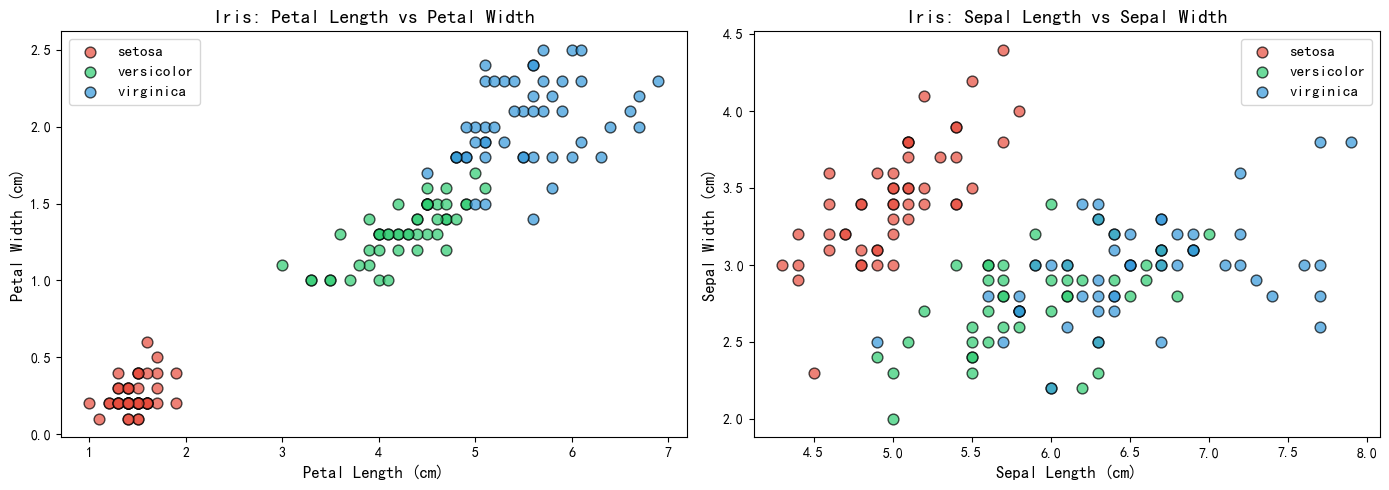

In [12]:
# 可视化特征与标签的关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：花瓣长度 vs 花瓣宽度
colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, target_name in enumerate(iris.target_names):
    mask = iris.target == i
    axes[0].scatter(iris.data[mask, 2], iris.data[mask, 3],
                    c=colors[i], label=target_name, alpha=0.7, edgecolors='k', s=60)

axes[0].set_xlabel('Petal Length (cm)', fontsize=12)
axes[0].set_ylabel('Petal Width (cm)', fontsize=12)
axes[0].set_title('Iris: Petal Length vs Petal Width', fontsize=14)
axes[0].legend(fontsize=11)

# 右图：花萼长度 vs 花萼宽度
for i, target_name in enumerate(iris.target_names):
    mask = iris.target == i
    axes[1].scatter(iris.data[mask, 0], iris.data[mask, 1],
                    c=colors[i], label=target_name, alpha=0.7, edgecolors='k', s=60)

axes[1].set_xlabel('Sepal Length (cm)', fontsize=12)
axes[1].set_ylabel('Sepal Width (cm)', fontsize=12)
axes[1].set_title('Iris: Sepal Length vs Sepal Width', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('iris_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 二、回归任务 vs 分类任务

监督学习的两大基本任务类型：

### 2.1 分类任务 (Classification)

预测**离散的类别标签**。

- **二分类**: 垃圾邮件检测（是/否）、疾病诊断（阳性/阴性）
- **多分类**: 手写数字识别（0-9）、图像分类（猫/狗/鸟）

**常用损失函数**: 交叉熵损失 (Cross-Entropy Loss)

$$\mathcal{L}_{CE} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

其中 $C$ 是类别数，$y_c$ 是真实标签的one-hot编码，$\hat{y}_c$ 是预测概率。

### 2.2 回归任务 (Regression)

预测**连续的数值**。

- 房价预测、股票价格预测、温度预测

**常用损失函数**: 均方误差 (Mean Squared Error, MSE)

$$\mathcal{L}_{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

### 2.3 直观对比

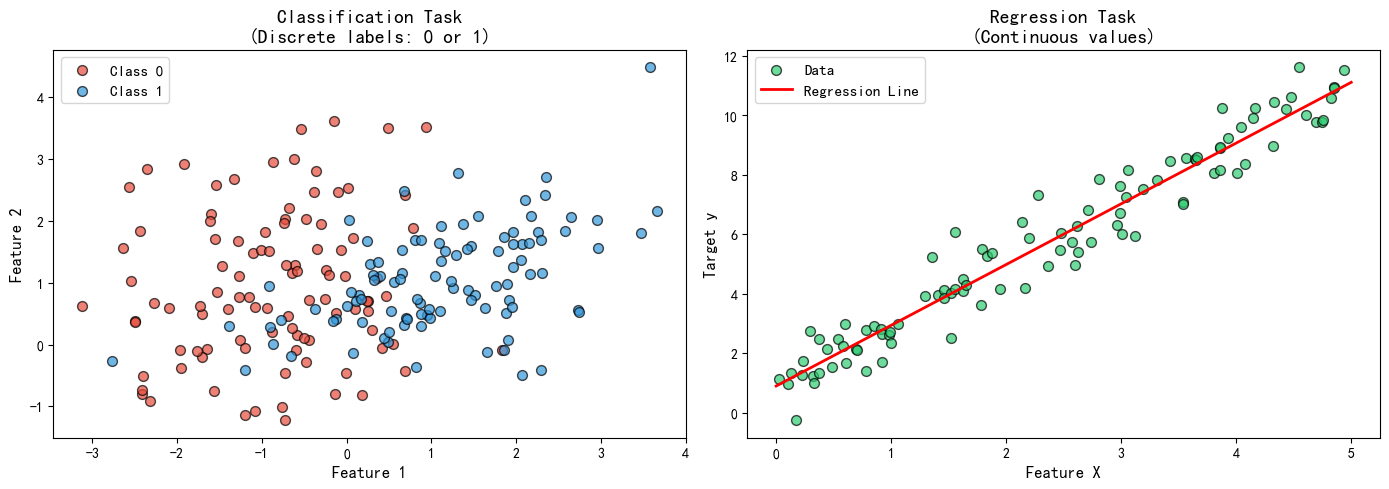

In [13]:
# 直观对比：分类 vs 回归
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：分类示例 - 决策边界
from sklearn.datasets import make_classification
X_cls, y_cls = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=42, n_clusters_per_class=1)
axes[0].scatter(X_cls[y_cls==0, 0], X_cls[y_cls==0, 1], c='#e74c3c',
                label='Class 0', alpha=0.7, edgecolors='k', s=50)
axes[0].scatter(X_cls[y_cls==1, 0], X_cls[y_cls==1, 1], c='#3498db',
                label='Class 1', alpha=0.7, edgecolors='k', s=50)
axes[0].set_title('Classification Task\n(Discrete labels: 0 or 1)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)

# 右图：回归示例 - 拟合曲线
X_reg = np.sort(5 * np.random.rand(100))
y_reg = 2 * X_reg + 1 + np.random.randn(100) * 0.8
axes[1].scatter(X_reg, y_reg, c='#2ecc71', alpha=0.7, edgecolors='k', s=50, label='Data')
# 拟合直线
z = np.polyfit(X_reg, y_reg, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 5, 100)
axes[1].plot(x_line, p(x_line), 'r-', linewidth=2, label='Regression Line')
axes[1].set_title('Regression Task\n(Continuous values)', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].set_xlabel('Feature X', fontsize=12)
axes[1].set_ylabel('Target y', fontsize=12)

plt.tight_layout()
plt.savefig('classification_vs_regression.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 对比总结

| 维度 | 分类 (Classification) | 回归 (Regression) |
|------|----------------------|-------------------|
| 输出类型 | 离散类别（如 0, 1, 2） | 连续数值（如 3.14, 99.5） |
| 损失函数 | 交叉熵损失 | MSE / MAE |
| 评估指标 | 准确率、精确率、召回率、F1 | MAE、MSE、R² |
| 典型算法 | 逻辑回归、SVM、决策树 | 线性回归、岭回归、SVR |
| 典型场景 | 图像分类、垃圾邮件检测 | 房价预测、温度预测 |

## 三、训练过程详解

模型训练是监督学习的核心步骤，包含四个关键环节：

```
输入 x  ──▶ [模型参数 W, b] ──▶ 预测 ŷ   (前向传播)
                                      │
                                      ▼
                               损失 L(ŷ, y)   (计算损失)
                                      │
                                      ▼
                               ∂L/∂W, ∂L/∂b    (反向传播)
                                      │
                                      ▼
                           W = W - η·∂L/∂W    (参数更新)
                           b = b - η·∂L/∂b
                                      │
                                      ▼
                                  (重复循环)
```

### 3.1 前向传播 (Forward Propagation)

将输入数据通过模型的层层计算，得到预测值：

$$\hat{y} = f(W \cdot x + b)$$

其中 $W$ 是权重矩阵，$b$ 是偏置，$f$ 是激活函数。

### 3.2 计算损失 (Loss Computation)

衡量预测值与真实值的差距：

- **MSE（回归）**: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$
- **交叉熵（分类）**: $\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c} y_{i,c}\log\hat{y}_{i,c}$

### 3.3 反向传播 (Backpropagation)

利用**链式法则**从输出层向输入层逐层计算梯度：

$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial W^{(l)}}$$

### 3.4 参数更新 (Parameter Update)

使用梯度下降法更新参数：

$$W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W^{(l)}}$$

其中 $\eta$ 是学习率（learning rate），控制每次更新的步长。

### 3.5 用代码理解训练过程

下面我们用纯 NumPy 实现一个简单的线性回归训练过程：

In [14]:
# ============================================
# 从零实现线性回归训练过程
# ============================================
np.random.seed(42)

# 生成模拟数据：y = 3x + 4 + noise
X = np.random.rand(100, 1) * 10  # 100个样本，1个特征
y_true = 3 * X.squeeze() + 4
y = y_true + np.random.randn(100) * 2  # 添加噪声

# 初始化参数
W = np.random.randn() * 0.01  # 权重
b = np.zeros(1)                # 偏置
lr = 0.01                      # 学习率
epochs = 200                   # 训练轮数

# 记录损失用于可视化
losses = []

# 训练循环
for epoch in range(epochs):
    # ---- 前向传播 ----
    y_pred = W * X.squeeze() + b
    
    # ---- 计算损失 (MSE) ----
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)
    
    # ---- 反向传播 (计算梯度) ----
    dW = np.mean(-2 * X.squeeze() * (y - y_pred))
    db = np.mean(-2 * (y - y_pred))
    
    # ---- 参数更新 (梯度下降) ----
    W = W - lr * dW
    b = b - lr * db
    
    # 修正：确保W和b为float标量再格式化字符串，否则format报错
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss:.4f}, W = {float(W):.4f}, b = {float(b):.4f}")

print(f"\n最终结果: W = {float(W):.4f} (真实值: 3.0), b = {float(b):.4f} (真实值: 4.0)")

Epoch  50: Loss = 5.7187, W = 3.3609, b = 1.4836
Epoch 100: Loss = 4.6554, W = 3.2510, b = 2.1990
Epoch 150: Loss = 4.0457, W = 3.1677, b = 2.7407
Epoch 200: Loss = 3.6961, W = 3.1047, b = 3.1509

最终结果: W = 3.1047 (真实值: 3.0), b = 3.1509 (真实值: 4.0)


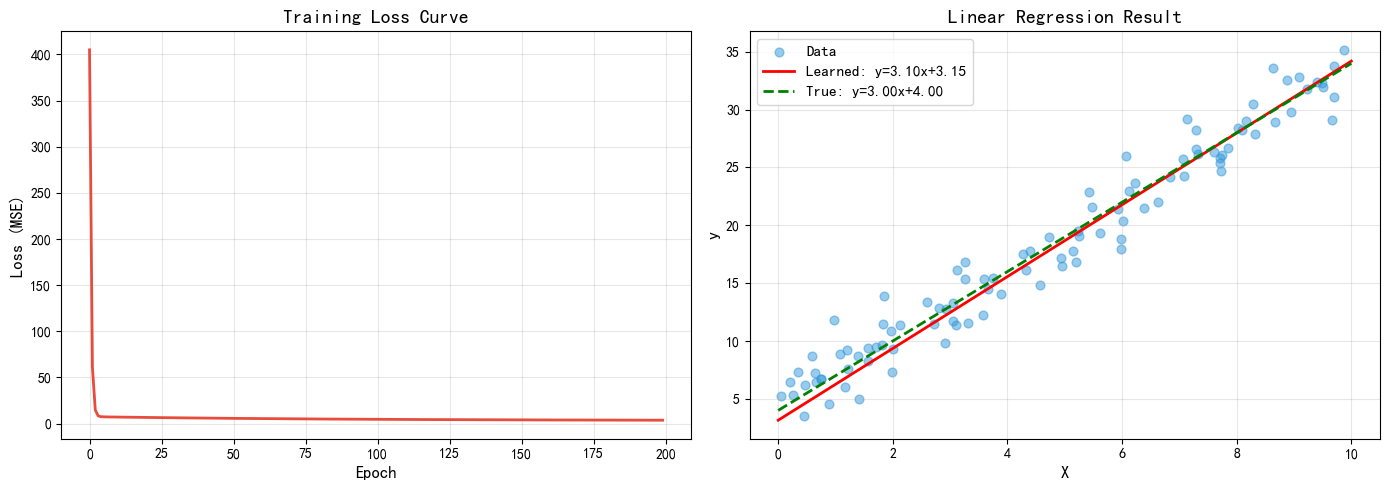

In [15]:
# 可视化训练过程
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：损失曲线
axes[0].plot(losses, color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss Curve', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 右图：回归结果
axes[1].scatter(X, y, alpha=0.5, c='#3498db', s=40, label='Data')
x_line = np.linspace(0, 10, 100)
W_plot = float(W)
b_plot = float(b)
axes[1].plot(x_line, W_plot * x_line + b_plot, 'r-', linewidth=2, label=f'Learned: y={W_plot:.2f}x+{b_plot:.2f}')
axes[1].plot(x_line, 3 * x_line + 4, 'g--', linewidth=2, label='True: y=3.00x+4.00')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Linear Regression Result', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_process.png', dpi=150, bbox_inches='tight')
plt.show()

## 四、推理过程 (Inference)

训练完成后，模型参数固定。推理就是用训练好的模型对新数据进行预测。

```python
# 推理过程伪代码
y_pred = trained_model.predict(new_X)  # 只做前向传播，不计算梯度
```

### 关键区别

| | 训练 (Training) | 推理 (Inference) |
|---|---|---|
| 目标 | 学习最优参数 $W, b$ | 使用参数做预测 |
| 梯度计算 | ✅ 需要 | ❌ 不需要 |
| 参数更新 | ✅ 更新 | ❌ 固定不变 |
| 计算量 | 大（含反向传播） | 小（仅前向传播） |
| 数据 | 训练集（带标签） | 新数据（无标签） |

**推理过程本质上就是一次前向传播：**

$$\hat{y} = f_{W^*, b^*}(x_{new})$$

其中 $W^*, b^*$ 是训练完成后得到的最终参数。

## 五、实战：Scikit-learn 分类 — 鸢尾花分类

现在让我们用 Scikit-learn 完成一个完整的分类任务。

In [16]:
# ============================================
# 完整分类流程：鸢尾花分类
# ============================================

# Step 1: 加载数据
iris = load_iris()
X = iris.data      # 特征矩阵 (150, 4)
y = iris.target    # 标签向量 (150,)

# Step 2: 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集大小: {X_train.shape[0]} 个样本")
print(f"测试集大小: {X_test.shape[0]} 个样本")
print(f"训练集类别分布: {np.bincount(y_train)}")
print(f"测试集类别分布: {np.bincount(y_test)}")

训练集大小: 120 个样本
测试集大小: 30 个样本
训练集类别分布: [40 40 40]
测试集类别分布: [10 10 10]


In [17]:
# Step 3: 特征缩放（标准化）
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # 注意：测试集只transform，不fit

print("标准化前 - 训练集均值:", np.mean(X_train, axis=0).round(2))
print("标准化后 - 训练集均值:", np.mean(X_train_scaled, axis=0).round(6))
print("标准化后 - 训练集标准差:", np.std(X_train_scaled, axis=0).round(6))

标准化前 - 训练集均值: [5.84 3.05 3.77 1.2 ]
标准化后 - 训练集均值: [-0. -0.  0.  0.]
标准化后 - 训练集标准差: [1. 1. 1. 1.]


In [18]:
# Step 4: 训练模型 (尝试多种分类器)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# 训练并评估每个模型
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}
for name, clf in classifiers.items():
    # 训练
    clf.fit(X_train_scaled, y_train)
    # 预测
    y_pred = clf.predict(X_test_scaled)
    # 评估
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25s} 准确率: {acc:.4f} ({acc*100:.1f}%)")

Logistic Regression       准确率: 0.9333 (93.3%)
Decision Tree             准确率: 0.9333 (93.3%)
Random Forest             准确率: 0.9000 (90.0%)
SVM (RBF Kernel)          准确率: 0.9667 (96.7%)
KNN (k=5)                 准确率: 0.9333 (93.3%)


In [19]:
# Step 5: 查看最佳模型的详细评估报告
best_model = SVC(kernel='rbf', random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print("分类报告:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("混淆矩阵:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

混淆矩阵:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


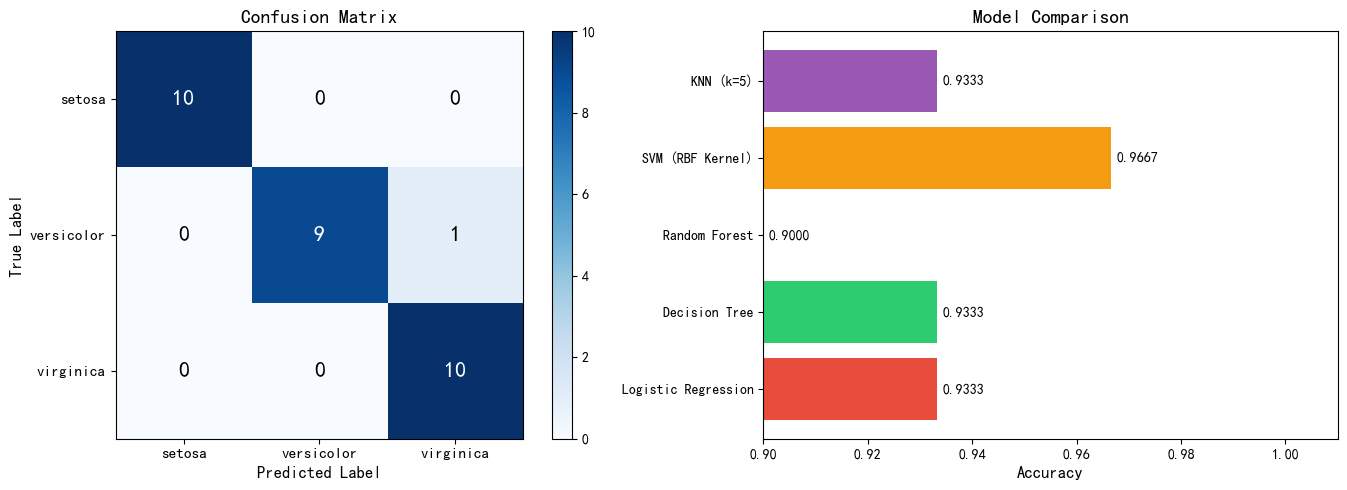

In [20]:
# Step 6: 可视化混淆矩阵
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 混淆矩阵热力图
im = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix', fontsize=14)
fig.colorbar(im, ax=axes[0])
tick_marks = np.arange(len(iris.target_names))
axes[0].set_xticks(tick_marks)
axes[0].set_xticklabels(iris.target_names, fontsize=11)
axes[0].set_yticks(tick_marks)
axes[0].set_yticklabels(iris.target_names, fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# 在格子中显示数字
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black", fontsize=16)

# 模型准确率对比
models = list(results.keys())
accuracies = list(results.values())
bars = axes[1].barh(models, accuracies, color=['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6'])
axes[1].set_xlim(0.9, 1.01)
axes[1].set_xlabel('Accuracy', fontsize=12)
axes[1].set_title('Model Comparison', fontsize=14)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{acc:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 六、实战：Scikit-learn 回归 — 加州房价预测

> **注意**: 原始波士顿房价数据集因伦理问题已从 Scikit-learn 中移除，我们使用加州房价数据集替代。

 california 房价数据集包含 20640 个加州街区，每个街区有 8 个特征。

In [21]:
# ============================================
# 完整回归流程：加州房价预测
# ============================================
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: 加载数据
california = fetch_california_housing()
X = california.data
y = california.target

print(f"特征名称: {california.feature_names}")
print(f"数据形状: {X.shape}")
print(f"标签范围: [{y.min():.2f}, {y.max():.2f}] (单位: 10万美元)")
print(f"标签均值: {y.mean():.2f}, 标准差: {y.std():.2f}")

特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据形状: (20640, 8)
标签范围: [0.15, 5.00] (单位: 10万美元)
标签均值: 2.07, 标准差: 1.15


In [22]:
# Step 2: 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"训练集: {X_train.shape[0]} 个样本")
print(f"测试集: {X_test.shape[0]} 个样本")

# Step 3: 特征缩放
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

# Step 4: 训练多个回归模型
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (α=1)": Ridge(alpha=1.0),
    "Lasso Regression (α=0.1)": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

reg_results = {}
for name, reg in regressors.items():
    reg.fit(X_train_scaled, y_train)
    y_pred = reg.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    reg_results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
    print(f"\n{name}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f} (平均偏差 {mae*10:.2f} 万美元)")
    print(f"  R²:  {r2:.4f}")

训练集: 16512 个样本
测试集: 4128 个样本

Linear Regression:
  MSE: 0.5559
  MAE: 0.5332 (平均偏差 5.33 万美元)
  R²:  0.5758

Ridge Regression (α=1):
  MSE: 0.5559
  MAE: 0.5332 (平均偏差 5.33 万美元)
  R²:  0.5758

Lasso Regression (α=0.1):
  MSE: 0.6796
  MAE: 0.6222 (平均偏差 6.22 万美元)
  R²:  0.4814

Random Forest:
  MSE: 0.2552
  MAE: 0.3274 (平均偏差 3.27 万美元)
  R²:  0.8053


C:\Users\Terry\AppData\Local\Temp\ipykernel_15816\2900719853.py:32: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_15816\2900719853.py:33: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


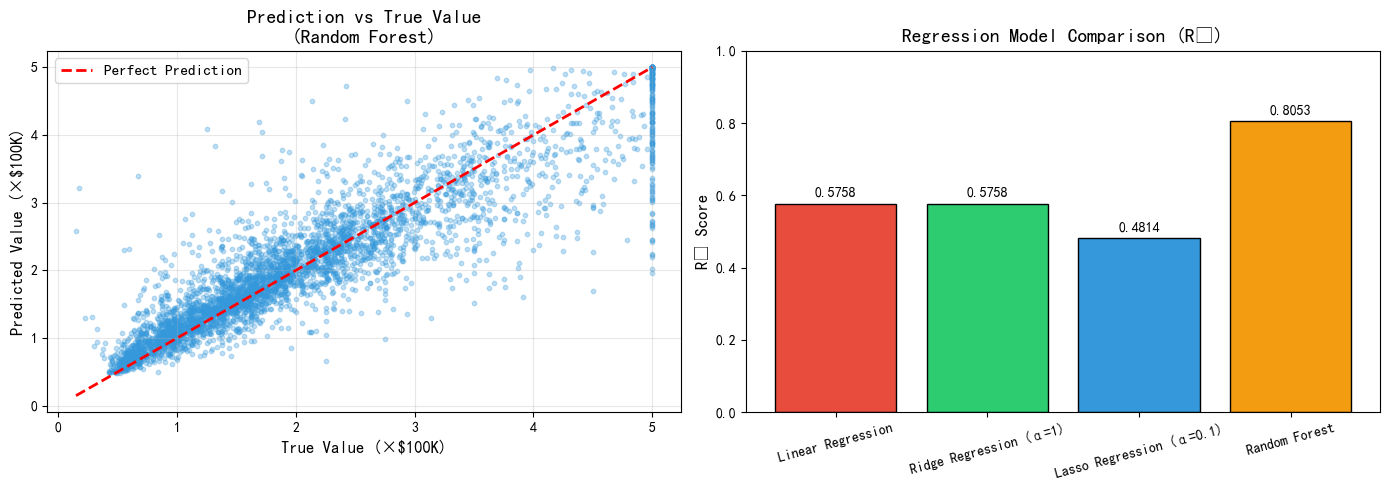

In [23]:
# Step 5: 可视化回归结果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 使用Random Forest的结果
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

# 左图：预测值 vs 真实值
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, c='#3498db')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('True Value (×$100K)', fontsize=12)
axes[0].set_ylabel('Predicted Value (×$100K)', fontsize=12)
axes[0].set_title('Prediction vs True Value\n(Random Forest)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右图：模型R²对比
models = list(reg_results.keys())
r2_values = [reg_results[m]['R2'] for m in models]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = axes[1].bar(models, r2_values, color=colors, edgecolor='black')
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Regression Model Comparison (R²)', fontsize=14)
axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 七、完整的训练/测试/评估流程总结

### 标准流程

```python
# 完整的监督学习标准流程

# 1. 加载数据
X, y = load_data()

# 2. 划分数据集: 训练集 / 验证集 / 测试集
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 3. 数据预处理 (特征缩放)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # 在训练集上fit
X_val   = scaler.transform(X_val)          # 在验证/测试集上只transform
X_test  = scaler.transform(X_test)

# 4. 训练模型
model.fit(X_train, y_train)

# 5. 在验证集上调参
y_val_pred = model.predict(X_val)
val_score = evaluate(y_val, y_val_pred)

# 6. 在测试集上最终评估
y_test_pred = model.predict(X_test)
test_score = evaluate(y_test, y_test_pred)

# 7. 使用模型进行推理
y_new = model.predict(new_data)
```

### 评估指标速查

| 指标 | 公式 | 适用场景 |
|------|------|----------|
| 准确率 (Accuracy) | $\frac{TP+TN}{TP+TN+FP+FN}$ | 分类（各类别均衡） |
| 精确率 (Precision) | $\frac{TP}{TP+FP}$ | 关注"预测为正的有多少是对的" |
| 召回率 (Recall) | $\frac{TP}{TP+FN}$ | 关注"真正的正样本有多少被找到" |
| F1 分数 | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | 精确率和召回率的调和平均 |
| MSE | $\frac{1}{N}\sum(y_i - \hat{y}_i)^2$ | 回归（对大误差敏感） |
| MAE | $\frac{1}{N}\sum|y_i - \hat{y}_i|$ | 回归（直观） |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | 回归（越接近1越好） |

In [24]:
# 补充：K折交叉验证 (K-Fold Cross Validation)
from sklearn.model_selection import cross_val_score

# 使用鸢尾花数据
X_iris, y_iris = load_iris(return_X_y=True)
scaler_cv = StandardScaler()
X_iris_scaled = scaler_cv.fit_transform(X_iris)

# 5折交叉验证
clf = LogisticRegression(max_iter=200, random_state=42)
cv_scores = cross_val_score(clf, X_iris_scaled, y_iris, cv=5, scoring='accuracy')

print("5折交叉验证结果:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: 准确率 = {score:.4f}")
print(f"\n平均准确率: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5折交叉验证结果:
  Fold 1: 准确率 = 0.9667
  Fold 2: 准确率 = 1.0000
  Fold 3: 准确率 = 0.9333
  Fold 4: 准确率 = 0.9000
  Fold 5: 准确率 = 1.0000

平均准确率: 0.9600 ± 0.0389


## 🏋️ 练习题

### 练习1：概念理解（选择题）

**Q1**: 在监督学习中，训练集和测试集的作用分别是什么？

- A) 训练集用于训练模型，测试集用于评估模型性能
- B) 训练集用于评估模型，测试集用于训练模型
- C) 训练集和测试集都用于训练模型
- D) 训练集和测试集都用于评估模型

**Q2**: 预测房价属于什么任务？预测邮件是否为垃圾邮件属于什么任务？

**Q3**: 在反向传播中，链式法则的作用是什么？

### 练习2：代码实践

**Q4**: 使用 Scikit-learn 的 `make_classification` 生成一个更复杂的二分类数据集（1000个样本，20个特征），然后：
1. 划分训练集（70%）和测试集（30%）
2. 训练一个逻辑回归模型
3. 输出准确率和分类报告
4. 绘制混淆矩阵热力图

In [25]:
# 练习2: 参考答案框架
# 请尝试自己完成，再参考下面的答案

# TODO: 尝试自己完成此练习

# === 参考答案 ===
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay

# 1. 生成数据
X_ex, y_ex = make_classification(n_samples=1000, n_features=20, n_informative=10,
                                 n_redundant=5, random_state=42)

# 2. 划分数据集
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    X_ex, y_ex, test_size=0.3, random_state=42
)

# 3. 特征缩放
scaler_ex = StandardScaler()
X_train_ex = scaler_ex.fit_transform(X_train_ex)
X_test_ex = scaler_ex.transform(X_test_ex)

# 4. 训练逻辑回归
clf_ex = LogisticRegression(max_iter=500, random_state=42)
clf_ex.fit(X_train_ex, y_train_ex)

# 5. 评估
y_pred_ex = clf_ex.predict(X_test_ex)
print(f"准确率: {accuracy_score(y_test_ex, y_pred_ex):.4f}")
print("\n分类报告:")
print(classification_report(y_test_ex, y_pred_ex))

准确率: 0.8367

分类报告:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       160
           1       0.80      0.87      0.83       140

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



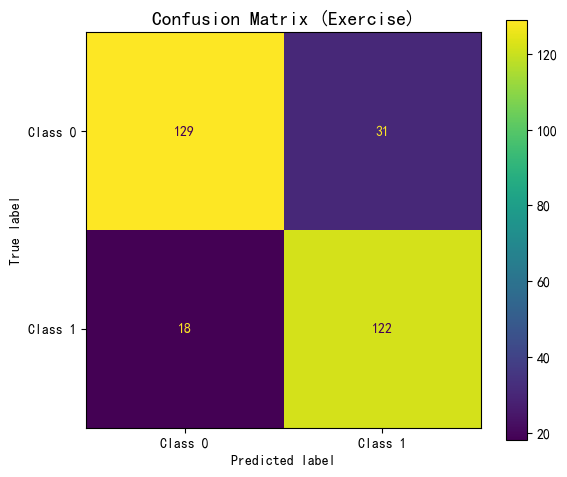

In [26]:
# 绘制混淆矩阵
fig, ax = plt.subplots(figsize=(6, 5))
cm_ex = confusion_matrix(y_test_ex, y_pred_ex)
ConfusionMatrixDisplay(confusion_matrix=cm_ex, display_labels=['Class 0', 'Class 1']).plot(ax=ax)
ax.set_title('Confusion Matrix (Exercise)', fontsize=14)
plt.tight_layout()
plt.show()

### 练习3：挑战题

**Q5**: 尝试修改从零实现的线性回归代码，将学习率分别设为 0.001、0.01、0.1，观察收敛速度和最终结果的差异，并解释原因。

**Q6**: 阅读以下代码，预测输出结果：
```python
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

model = LinearRegression()
model.fit(X, y)
print(model.predict([[6]]))  # 预测结果是什么？
print(model.coef_, model.intercept_)  # 权重和偏置是什么？
```


---

## 📌 本节小结

| 知识点 | 要点 |
|--------|------|
| 监督学习框架 | 训练集 → 特征+标签 → 模型 → 预测 |
| 回归 vs 分类 | 连续数值 vs 离散类别 |
| 训练过程 | 前向传播 → 损失计算 → 反向传播 → 参数更新 |
| 推理过程 | 固定参数，仅做前向传播 |
| 评估指标 | 分类：Accuracy/F1；回归：MSE/R² |

**下一节**: [5.2 无监督学习](./5.2_无监督学习.ipynb)